# **STATS 503, Group Work Assignment 9: PCA and Clustering**

**Instructions:** During lab section, and afterward as necessary, you will collaborate in two-person teams (assigned by the GSI) to complete the problems that are interspersed below. The GSI will help individual teams encountering difficulty, make announcements addressing common issues, and help ensure progress for all teams. **During lab, feel free to flag down your GSI to ask questions at any point!** Upon completion, one member of the team should submit their team's work through Canvas as html.

**Credits:** Roman Kouznetsov, based on the notes of Gang Qiao

**Acknowledgments:** Several code snippets were taken from [the following repository](https://nbisweden.github.io/workshop-archive/workshop-scRNAseq/2020-01-27/labs/compiled/scanpy/scanpy_04_clustering.html).

## Review of PCA and Clustering

First, let's review how to use Python for PCA and clustering. We start with some theory about PCA.**

### PCA


- PCA replaces the original $p$ variables with $d<p$ linear combinations of the original variables that are a “good representation” of the data.


- Mathematical formulation of PCA: The problem is to find the $k$ th new variable $Z_k$ which is a linear combination of the original variables $X_1, X_2, \cdots, X_p$ (i.e. $\left.Z_k=\sum_{j=1}^p w_{k j} X_j\right)$ such that it maximizes
  $$
  w_k^T \Sigma w_k \\
  \text { subject to } w_k^T w_k=1, w_k^T w_{k^{\prime}}=0, k^{\prime}<k
  $$

  The solution to the above problem is given by the eigendecomposition of $\Sigma$: \\
  $\Sigma=W \Lambda W^T$, where $W$ is a  $p \times p$ matrix of (column) eigenvectors and $\Lambda$ is a $p \times p$ diagonal matrix of eigenvalues.


- PCA in practice: Let $X_{n \times p}$ now be the $n \times p$ data matrix (centered). Each data point is represented by a row.
    - Compute the sample covariance matrix $\hat{\Sigma}= \frac{1}{n-1}X^{\top} X$
    - Vectors $w_k$ 's are the eigenvectors of $\hat{\Sigma}$ and are called **PC directions**. The coordinates $w_{k j}$ are called **(factor) loadings**.
    - Vectors $z_k=X w_k(k=1, \ldots, d)$ are called the **principal components** of $X$ and are projections of the data onto the PC directions. Components of $X w_k$ are also called scores.
    - $\operatorname{var}\left(X w_k\right)=\lambda_k$, the eigenvalues of $\hat{\Sigma} ; \lambda_1 \geq \lambda_2 \geq \ldots \lambda_p \geq 0$.
    
    
- How to pick the number of PCs?
  - For visualization, can only use 2 or 3
  - Can choose $d$ to explain certain percent of variation: pick first $d$ so that $\frac{\sum_{k=1}^d \lambda_k}{\sum_{k=1}^p \lambda_k} \geq (1-\alpha)$
    for some pre-specified small alpha (e.g. 0.1)
  - Scree plot: plot $\lambda_k$ or $\sqrt{\lambda_k}$ against $k$ and look for an 'elbow'

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Now we use the crab dataset for a PCA practice.

In [36]:
crabs = pd.read_csv('crabs.csv', index_col=0)
crabs.index = crabs["index"]
crabs.drop(columns = ['index'], inplace = True)

In [37]:
crabs.shape

(200, 7)

``sp``: species - "B" or "O" for blue or orange.

``sex``: male or female

``index``: index 1:50 within each of the four groups.

``FL``: frontal lobe size (mm).

``RW``: rear width (mm).

``CL``: carapace length (mm).

``CW``: carapace width (mm).

``BD``: body depth (mm).

In [38]:
crabs.head()

,sp,sex,FL,RW,CL,CW,BD
index,,,,,,,
1,B,M,8.1,6.7,16.1,19.0,7.0
2,B,M,8.8,7.7,18.1,20.8,7.4
3,B,M,9.2,7.8,19.0,22.4,7.7
4,B,M,9.6,7.9,20.1,23.1,8.2
5,B,M,9.8,8.0,20.3,23.0,8.2


In [39]:
crabs.describe()

,FL,RW,CL,CW,BD
count,200.000000,200.00000,200.000000,200.000000,200.000000
mean,15.583000,12.73850,32.105500,36.414500,14.030500
std,3.495325,2.57334,7.118983,7.871955,3.424772
min,7.200000,6.50000,14.700000,17.100000,6.100000
25%,12.900000,11.00000,27.275000,31.500000,11.400000
50%,15.550000,12.80000,32.100000,36.800000,13.900000
75%,18.050000,14.30000,37.225000,42.000000,16.600000
max,23.100000,20.20000,47.600000,54.600000,21.600000


In [40]:
crabs.describe(include = 'object')

,sp,sex
count,200,200
unique,2,2
top,B,M
freq,100,100


Now, we use the 4 numerical (continuous) variables to perform PCA.

In [41]:
X = crabs.iloc[:,3:]
X.head()

,RW,CL,CW,BD
index,,,,
1,6.7,16.1,19.0,7.0
2,7.7,18.1,20.8,7.4
3,7.8,19.0,22.4,7.7
4,7.9,20.1,23.1,8.2
5,8.0,20.3,23.0,8.2


In [42]:
from sklearn.decomposition import PCA

In [43]:
pca = PCA(svd_solver = 'full')
pca.fit(X)

PCA(svd_solver='full')

In [44]:
# By default, it is min(n_features, n_samples)
pca.n_components_

4

We can get the amount of variance explained by each of the selected components by using the attribute ``explained_variance_``. Note that it corresponds to the eigenvalue $\lambda_k$.

In [45]:
pca.explained_variance_

array([1.28998080e+02, 1.23209821e+00, 6.89092074e-01, 7.94701148e-02])

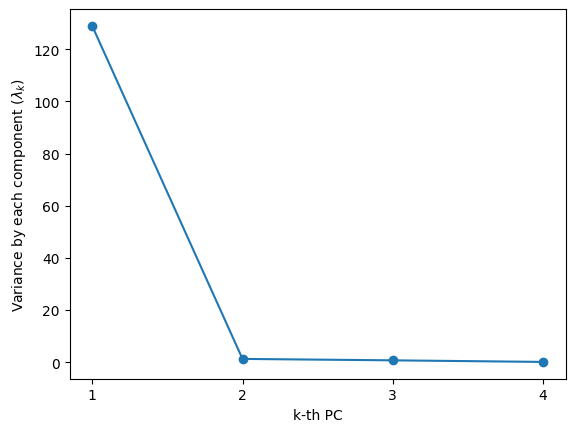

In [46]:
plt.plot(range(1, pca.n_components_+1), pca.explained_variance_, '-o')
plt.xticks(range(1,pca.n_components_+1)) # This line makes sure that the x-axis only shows the integer values
plt.xlabel('k-th PC')
plt.ylabel(r'Variance by each component ($\lambda_k$) ')
plt.show()

The percentage of variance explained by each of the selected components is calculated as follows:

In [47]:
np.round(
    pca.explained_variance_ratio_,
    3
)

array([0.985, 0.009, 0.005, 0.001])

The tranformed data (the scores) can be calculated as follows:

In [48]:
Z = pca.transform(X)
print(Z.shape)

(200, 4)


Now we try to visualize the first two dimensions based on the PCA results.

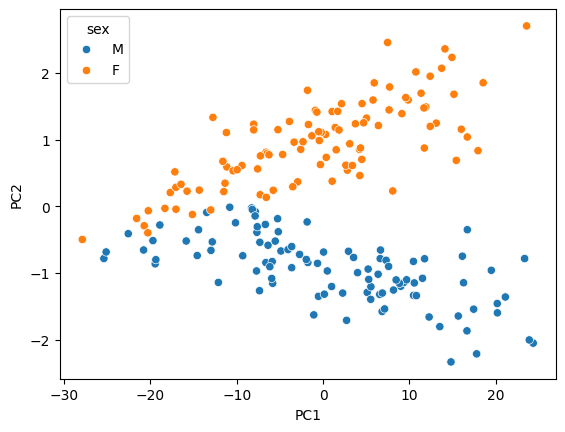

In [49]:
sns.scatterplot(x = Z[:, 0], y = Z[:, 1], hue= crabs['sex'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

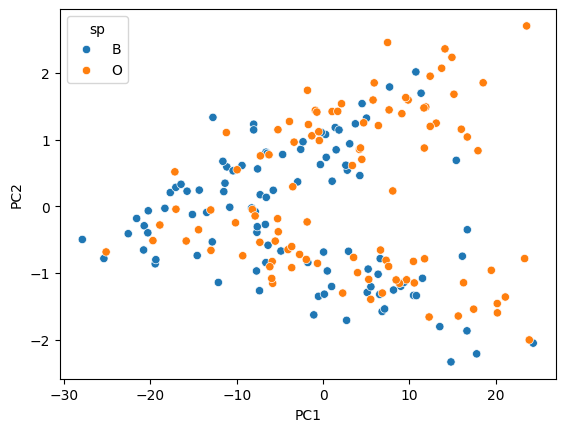

In [50]:
sns.scatterplot(x = Z[:, 0], y = Z[:, 1], hue= crabs['sp'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### Clustering

A dendrogram is a diagram representing a tree. The figure factory called create_dendrogram performs hierarchical clustering on data and represents the resulting tree. Values on the tree depth axis correspond to distances between clusters.

Dendrogram plots are commonly used in computational biology to show the clustering of genes or samples, sometimes in the margin of heatmaps.

In [51]:
import plotly.figure_factory as ff
import numpy as np
np.random.seed(1)

X = np.random.rand(15, 12) # 15 samples, with 12 dimensions each
fig = ff.create_dendrogram(X)
fig.update_layout(width=800, height=500)
fig.show()

We can also set up a height or threshold manually.

In [52]:
X = np.random.rand(15, 10) # 15 samples, with 10 dimensions each
fig = ff.create_dendrogram(X, color_threshold=1.5)
fig.update_layout(width=800, height=500)
fig.show()

Now we practice another clustering method: K-means clustering. We work on a synthetic baby data.

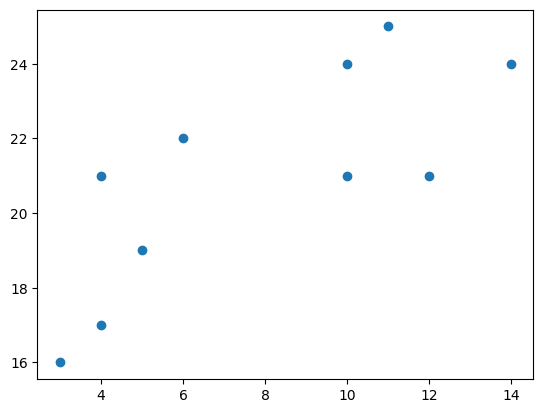

In [53]:
import matplotlib.pyplot as plt

x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

plt.scatter(x, y)
plt.show()

"Inertia," also known as within-cluster sum of squares (WSS), measures squared distances between points and the centroid of their cluster.  It is equal to one-half the within-cluster variation (i.e., sum of squared distance between all pairs of points in the same cluster, divided by size of cluster, summed over all clusters).

Now we utilize the elbow method to visualize the intertia for different values of K:

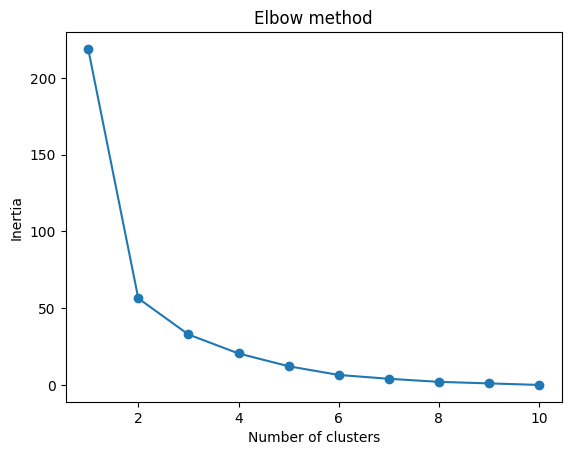

In [54]:
from sklearn.cluster import KMeans

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

The elbow method shows that 2 is a good value for K, so we retrain and visualize the result using K=2.

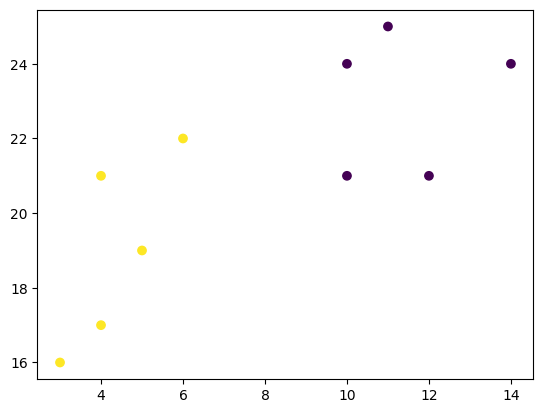

In [55]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()



---


# Problems (30 points)

We have demonstrated how PCA works, but really, moving from 6 variables to 2 principal components is a trivial exercise. PCA is most effective when the data is truly of higher dimension.

### Part 1: Syntetic Data Genenration (3 points)

Let's generate some data of rank 3. Let's create 250 observations of features $z \sim MVN([5, 3, 1], I)$. Then, let's create a low rank matrix by creating a data matrix $X$ such that $X = ZL + \epsilon$, where $\epsilon \sim N(0, 0.25)$.

In [11]:
import numpy as np
mean = [5, 3, 1]
cov = np.identity(3)
Z = np.random.multivariate_normal(mean, cov, size=250)
L = np.random.normal(0, 1, (3,50))

X = np.matmul(Z, L)
X += np.random.normal(0, 0.25, X.shape)


### Part 2: Clustering on All Data (3 points)

Please create a subplots collection of 2 rows and 3 plotting cluster plots with K-Means ranging from $K=2,3,\dots,7$. Use the entire dataset of X.

**NOTE**: Your plot should be organized as a collection of subplots. 6 separate plots that span vertically will not be given credit.

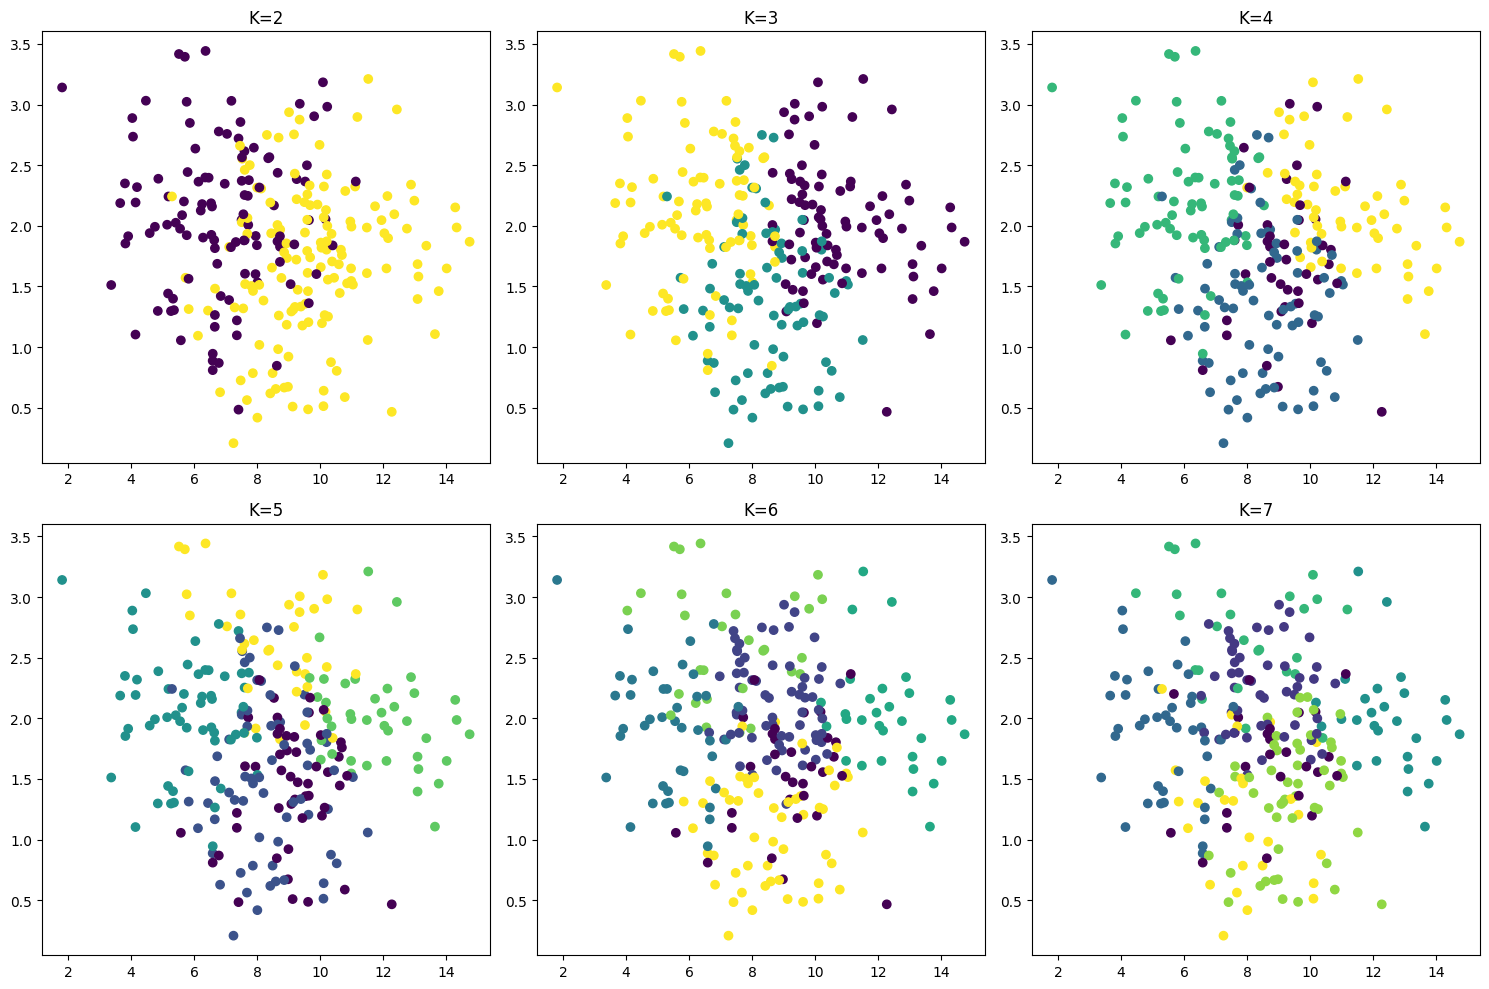

In [12]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

NUM_ROWS, NUM_COLS = 2, 3

for k in range(2, 8):
  ### YOUR CODE HERE
  km_model = KMeans(n_clusters=k, random_state=0)
  km_model.fit(X)
  ax[int((k-2)/3), (k-2)%3].scatter(X[:, 0], X[:, 1], c=km_model.labels_)
  ax[int((k-2)/3), (k-2)%3].set_title(f'K={k}')


plt.tight_layout()
plt.show()

Hmmm. Not bad, but the 3 clusters we know to exist from construction don't look super separable. Perhaps using just 2 random features in the input space (which we know is a subsset of features from a low rank matrix) was a recipe for disaster. Let's instead see if projecting to a lower dimensional space (creating latent features), yields separable clusters.

### Part 3: Recovering Principal Components (2 points)

Run PCA with a reasonable number of components. Assess the total variance explained by PCs. Based on this assessment, decide how many PCs we should use for downstream clustering and include this answer in markdown. Please include a plot of the cumulative sum of variance explained by PCA.

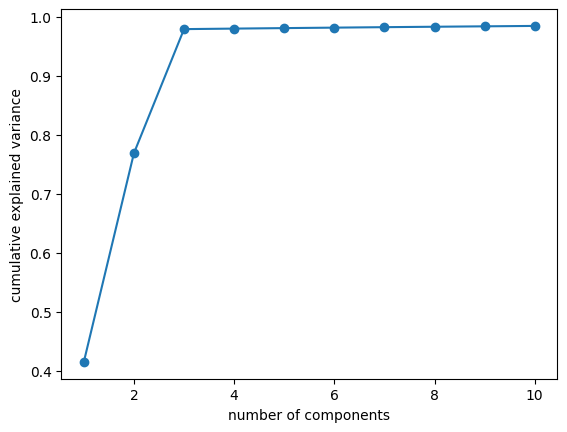

In [30]:
### YOUR CODE HERE
from sklearn.decomposition import PCA
pca = PCA(svd_solver='full', n_components=10)
pca.fit(X)
explained_variance_cumsum = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, pca.n_components_+1), explained_variance_cumsum, '-o')
# plt.xticks(range(1,pca.n_components_+1))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

**NUMBER OF PCs TO USE**: _3_

## Part 4: Interpreting PCA Space

### Part 4a (Code): Improving Visualization (3 points)

Now that we have established how many principal components to use that accurately summarizes our data, let's try to see how many clusters are visually separable in latent space. Please create a subplots collection of 2 rows and 3 plotting cluster plots with K-Means ranging from $K=2,3,\dots,7$.

**NOTE**: Your plot should be organized as a collection of subplots. 6 separate plots that span vertically will not be given credit.

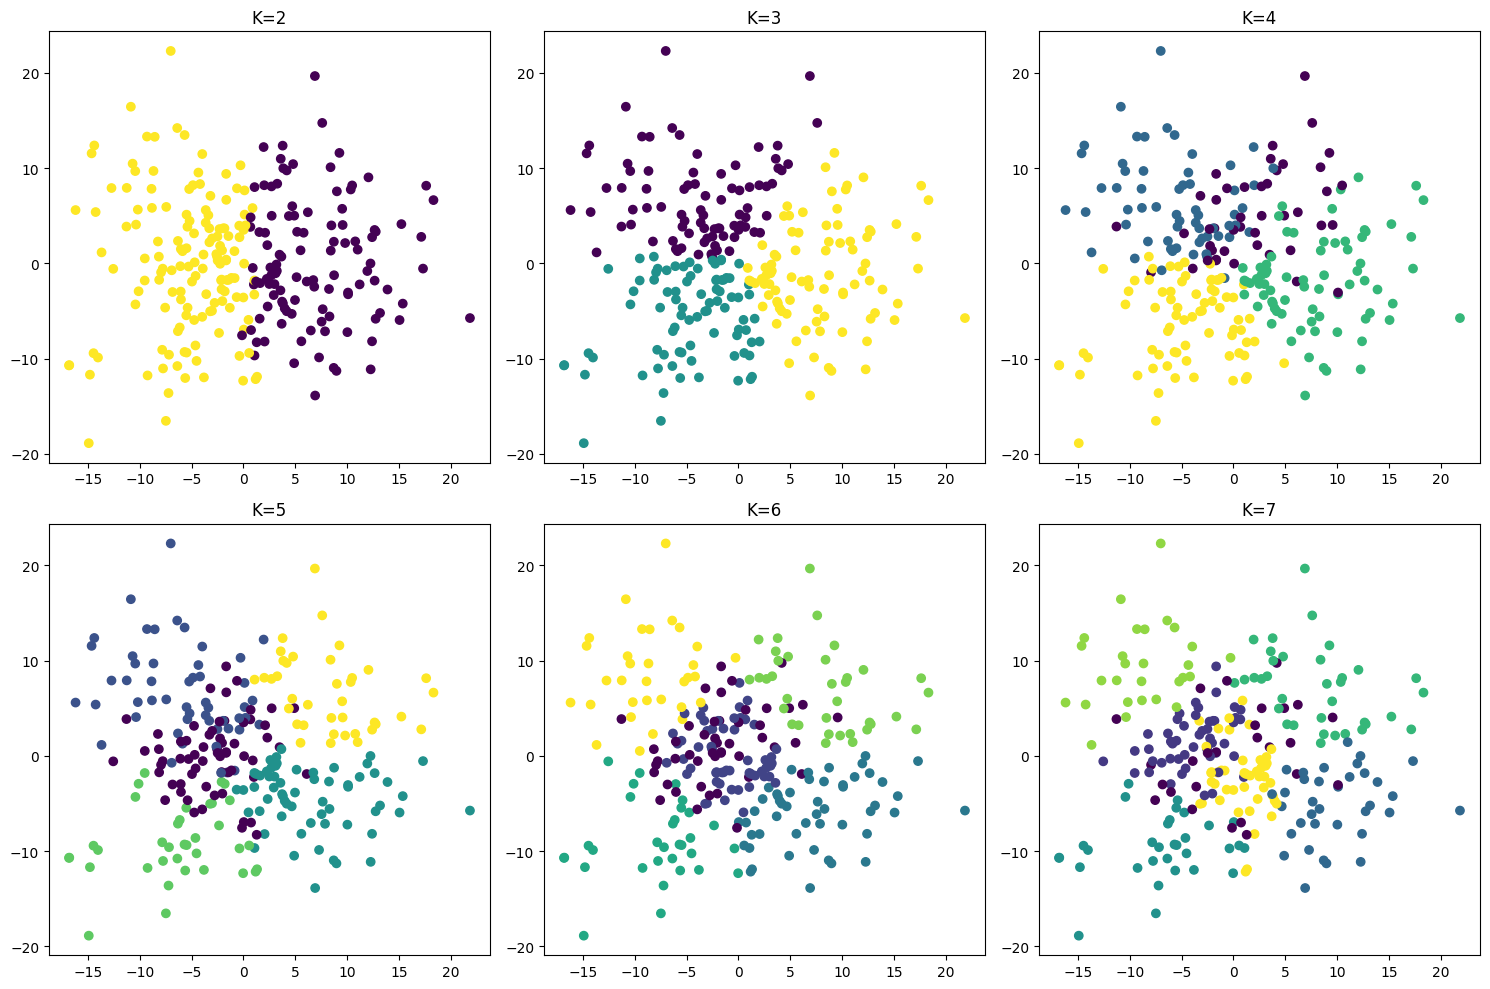

In [31]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

NUM_ROWS, NUM_COLS = 2, 3

for k in range(2, 8):

  ### YOUR CODE HERE
  pca = PCA(svd_solver='full', n_components=3)
  data = pca.fit_transform(X)
  km_model = KMeans(n_clusters=k, random_state=0)
  km_model.fit(data)

  ax[int((k-2)/3), (k-2)%3].scatter(data[:, 0], data[:, 1], c=km_model.labels_)
  ax[int((k-2)/3), (k-2)%3].set_title(f'K={k}')

plt.tight_layout()
plt.show()

### Part 4b (Writing): Interpreting PCA Space (1 point)

In **1-2 sentences MAX**, please explain how to interpret the axes of the cluster plots using PCA data and why the clusters were visually separable in PCA space.

**YOUR ANSWER HERE**.
The axes of the cluster plots represent the first two principal components (PC1 and PC2) after performing PCA with 3 components.  The clusters are visually separable because PCA projects the data into a lower-dimensional space where the most important features (variance) are emphasized, allowing natural groupings to become more apparent.



---


Gene data is a really good example of real data that typically requires dimensionality reduction. Some datasets have tens of thousands of genes included. We will work with a data set that has been reduced for us thanks to the [scanpy](https://scanpy.readthedocs.io/en/stable/generated/scanpy.datasets.pbmc68k_reduced.html#scanpy.datasets.pbmc68k_reduced) library.

We have included the relevant code needed to load the dataset into the notebook. Please note that the data is an [annotated data matrix](https://anndata.readthedocs.io/en/stable/). It's a class that handles data organization, usually for single cell data.

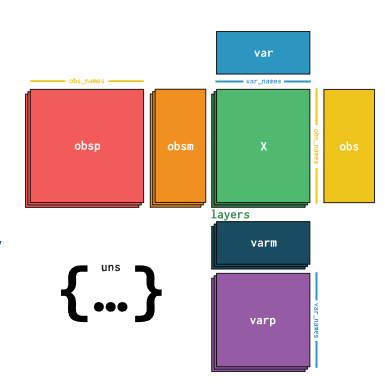

Here is a quick summary of each anndata component (you won't need to use them all for this lab).

- **X**: The primary two-dimensional data matrix (e.g. gene expression) where rows usually correspond to cells and columns to features (genes).

- **obs**: A DataFrame storing per-observation (often per-cell) annotations such as cluster labels or metadata.

- **var**: A DataFrame storing per-variable (often per-gene) annotations like gene symbols or feature quality metrics.

- **uns**: A dictionary-like structure for unstructured annotations, typically holding things like color schemes, parameter settings, or additional metadata.

- **obsm**: A dictionary of matrices aligned with observations (cells), commonly used for embeddings (e.g. PCA, UMAP coordinates).

- **varm**: A dictionary of matrices aligned with variables (genes), often used for storing feature loadings in dimensionality reduction.

- **layers**: A dictionary of additional data layers (e.g. raw counts, imputed data) that share the same dimensionality as X but may differ in values.

- **raw**: An optional structure holding the unmodified or “raw” version of the data matrix (plus corresponding var), often used to preserve counts before normalization or filtering.


---



## Part 5: Working with scanpy Datasets (3 points)

We have included the installation of scanpy and the dataset load-in.

1. Using the data matrix X and the PCA matrix X_pca, please write the number of obserations as well as the number of features in each dataset in the assert statement block.
2. The bulk_labels object has the annotations of each cell's cell type. In the arkdown, please include how many unique cell types there are.

In [18]:
%%capture
# JUST RUN, DO NOT EDIT
!pip install scanpy

In [19]:
# JUST RUN, DO NOT EDIT
import scanpy as sc

# Load the pbmc68k dataset
adata = sc.datasets.pbmc68k_reduced()

# Inspect the AnnData object
print(adata)

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [29]:
# YOUR CODE TO EXTRACT SHAPES HERE
X_shape_x, X_shape_y = adata.X.shape
X_pca_shape_x, X_pca_shape_y = adata.obsm["X_pca"].shape
print(f"X_shape_x: {X_shape_x}")
print(f"X_shape_y: {X_shape_y}")
print(f"X_pca_shape_x: {X_pca_shape_x}")
print(f"X_pca_shape_y: {X_pca_shape_y}")

# bulk_labels
print(len(adata.obs["bulk_labels"].unique()))

X_shape_x: 700
X_shape_y: 765
X_pca_shape_x: 700
X_pca_shape_y: 50
10


In [23]:
# INFILL RIGHT HAND SIDE HERE

assert adata.X.shape[0] == 700 # num cells in X
assert adata.X.shape[1] == 765 # num genes in X
assert adata.obsm["X_pca"].shape[0] == 700 # num cells in X_pca
assert adata.obsm["X_pca"].shape[1] ==  50# num PCs authors decided to include in dataset

**ANSWER: There are** 10 **unique cell types.**

## Part 6: Clustering Genomic Data with K-means

### Part 6a: K-means with Raw Data (3 points)

Let's perform K-means clustering on all the data first. Please infill the missing code with K-means clusters based on the WHOLE genetic dataset. Let's use K = {5, 10, 15}. Additionally, please include the KMeans annotations in the per-obsertvation annotations (obs). The K=5 example is included for you.

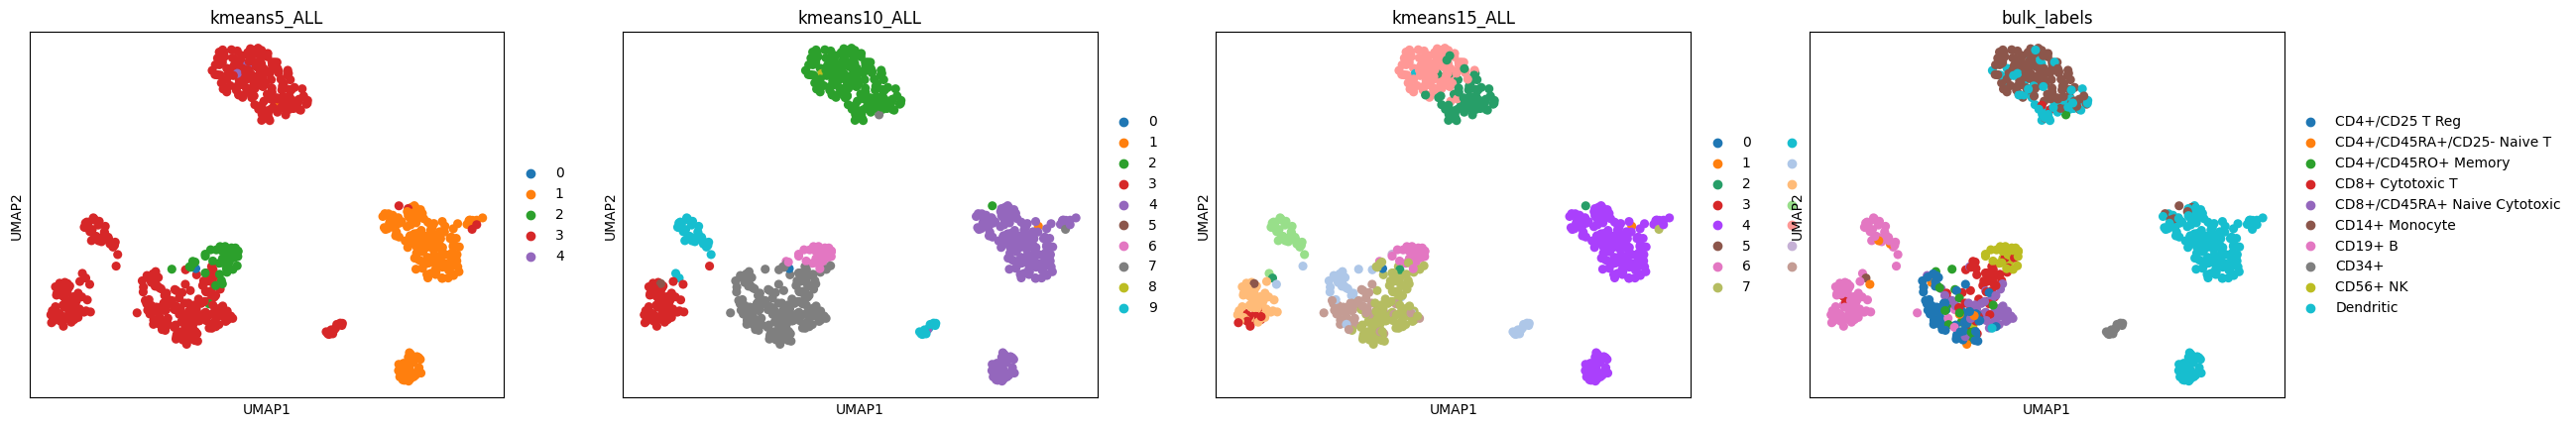

In [33]:
X = adata.X

# kmeans with k=5
kmeans5 = KMeans(n_clusters=5, random_state=0).fit(X)
adata.obs['kmeans5_ALL'] = kmeans5.labels_.astype(str)

# kmeans with k=10
kmeans10 = KMeans(n_clusters=10, random_state=0).fit(X)
adata.obs['kmeans10_ALL'] = kmeans10.labels_.astype(str)

# kmeans with k=15
kmeans15 = KMeans(n_clusters=15, random_state=0).fit(X)
adata.obs['kmeans15_ALL'] = kmeans15.labels_.astype(str)

# This plots points in low-dim UMAP space to visualize your clusters. Color strings represents obs keys.
sc.pl.umap(adata, color=['kmeans5_ALL', 'kmeans10_ALL', 'kmeans15_ALL', 'bulk_labels'])

### Part 6b: K-means with Principal Components (3 points)

Now, let's do the same thing except now using the principal components as clustering input.

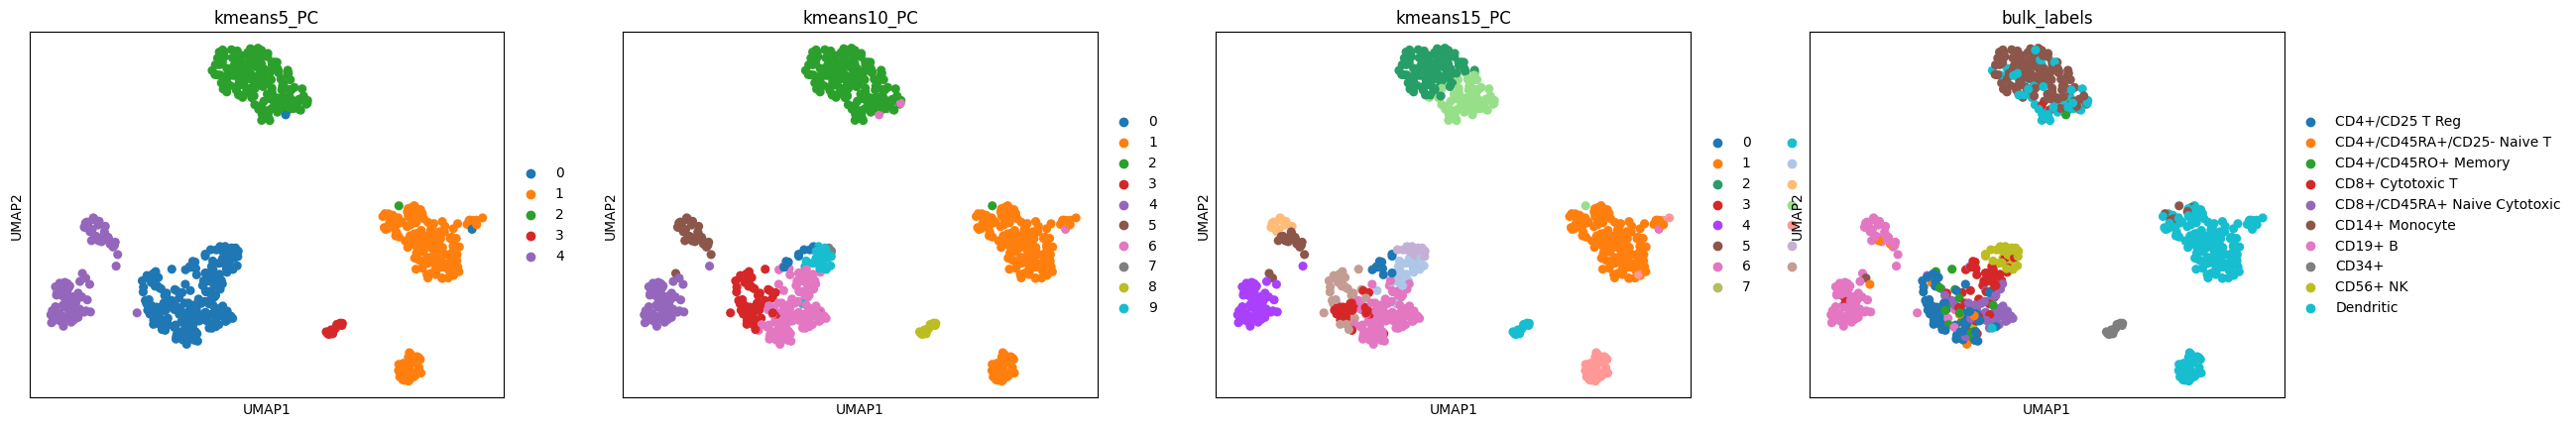

In [34]:
# extract pca coordinates
X_pca = adata.obsm['X_pca']

# kmeans with k=5
k5_pca = KMeans(n_clusters=5, random_state=0).fit(X_pca)
adata.obs['kmeans5_PC'] = k5_pca.labels_.astype(str)

# kmeans with k=10
k10_pca = KMeans(n_clusters=10, random_state=0).fit(X_pca)
adata.obs['kmeans10_PC'] = k10_pca.labels_.astype(str)

# kmeans with k=15
k15_pca = KMeans(n_clusters=15, random_state=0).fit(X_pca)
adata.obs['kmeans15_PC'] = k15_pca.labels_.astype(str)
# This plots points in low-dim UMAP space to visualize your clusters. Color strings represents obs keys.
sc.pl.umap(adata, color=['kmeans5_PC', 'kmeans10_PC', 'kmeans15_PC', 'bulk_labels'])

## Part 7: Hierarchical Clustering for Genomic Data

### Part 7a: Hierarchical Clustering with Raw Data (3 points)

Let's perform Agglomorative (Hierarchical) clustering on all the data first. Please infill the missing code with Hierarchical clusters based on the WHOLE genetic dataset. Let's use `n_clusters = {5, 10, 15}`. Additionally, please include the KMeans annotations in the per-obsertvation annotations (obs). The K=5 example is included for you.

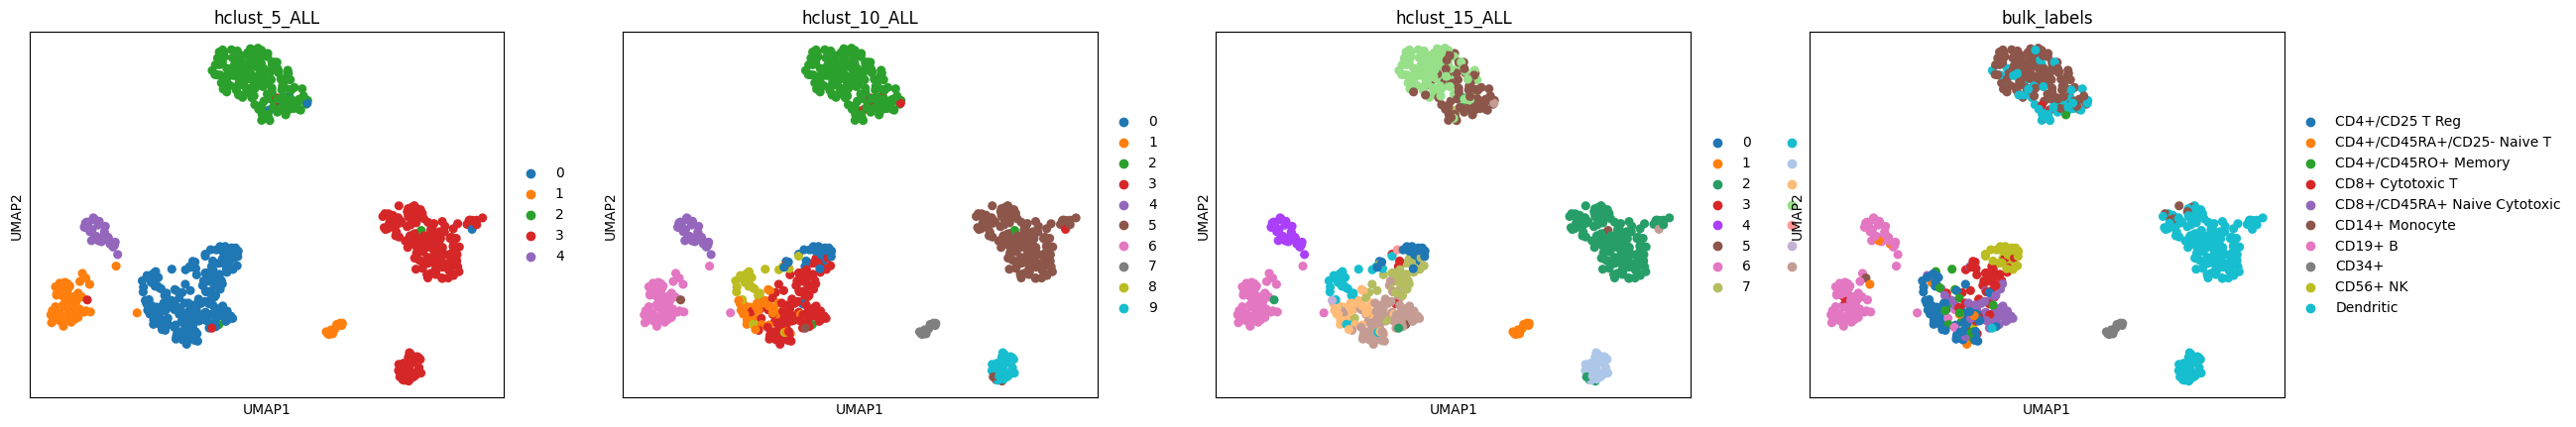

In [57]:
from sklearn.cluster import AgglomerativeClustering
X = adata.X
# hclust with 5 clusters
cluster5 = AgglomerativeClustering(n_clusters=5)
adata.obs['hclust_5_ALL'] = cluster5.fit_predict(X).astype(str)

# hclust with 10 clusters
cluster10 = AgglomerativeClustering(n_clusters=10)
adata.obs['hclust_10_ALL'] = cluster10.fit_predict(X).astype(str)

# hclust with 15 clusters
cluster15 = AgglomerativeClustering(n_clusters=15)
adata.obs['hclust_15_ALL'] = cluster15.fit_predict(X).astype(str)

# This plots points in low-dim UMAP space to visualize your clusters. Color strings represents obs keys.
sc.pl.umap(adata, color=['hclust_5_ALL', 'hclust_10_ALL', 'hclust_15_ALL', 'bulk_labels'])

### Part 7b: Hierarchical Clustering with Principal Components (3 points)

Now, let's do the same thing except now using the principal components as clustering input.

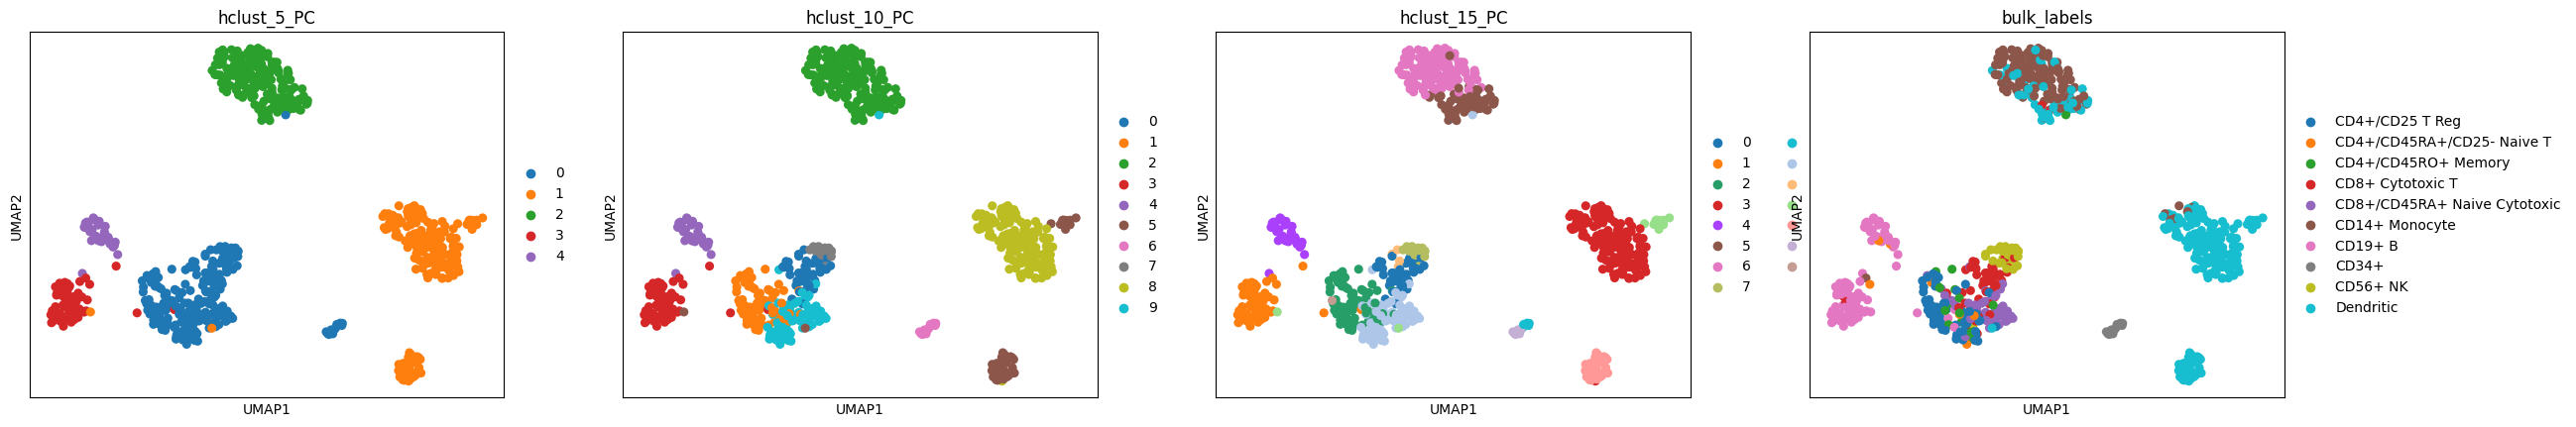

In [58]:
from sklearn.cluster import AgglomerativeClustering

X_pca = adata.obsm['X_pca']
# hclust with 5 clusters
cluster5_pca = AgglomerativeClustering(n_clusters=5)
adata.obs['hclust_5_PC'] = cluster5_pca.fit_predict(X_pca).astype(str)

# hclust with 10 clusters
cluster10_pca = AgglomerativeClustering(n_clusters=10)
adata.obs['hclust_10_PC'] = cluster10_pca.fit_predict(X_pca).astype(str)

# hclust with 15 clusters
cluster15_pca = AgglomerativeClustering(n_clusters=15)
adata.obs['hclust_15_PC'] = cluster15_pca.fit_predict(X_pca).astype(str)

# This plots points in low-dim UMAP space to visualize your clusters. Color strings represents obs keys.
sc.pl.umap(adata, color=['hclust_5_PC', 'hclust_10_PC', 'hclust_15_PC', 'bulk_labels'])

## Part 8: Evaluating Cluster Assignments (3 points)

Ok, we have ran all the clustering algorithms, but maybe just looking at the cluster assignments is not a great way to evaluate them. One cluster evaluation metric is the [adjusted rand index (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html). You do not have to fully understand the formula, just know that scores closer to 1 mean nearly identical clusters while values 0 or below represent random or discordant clusters.

Use the ARI on all previous clustering to determine which clustering worked the best. In **1-2 sentences MAX**, write which cluster had the highest ARI **and if that conclusion makes sense**.

In [59]:
from sklearn.metrics import adjusted_rand_score

all_clusters = ['kmeans5_ALL', 'kmeans10_ALL', 'kmeans15_ALL',
                'kmeans5_PC', 'kmeans10_PC', 'kmeans15_PC',
                'hclust_5_ALL', 'hclust_10_ALL', 'hclust_15_ALL',
                'hclust_5_PC', 'hclust_10_PC', 'hclust_15_ALL']

max_ari = 0
best_clustering = None
for cluster in all_clusters:
    ari = adjusted_rand_score(adata.obs['bulk_labels'], adata.obs[cluster])
    if ari > max_ari:
        max_ari = ari
        best_clustering = cluster

print(f"The best clustering was {best_clustering} with an ARI of {max_ari}")

The best clustering was kmeans10_PC with an ARI of 0.594164939334593


**YOUR ANSWER HERE**
"kmeans10_PC" has the highest ARI. This makes sense because PCA reduces the dimensionality while preserving the most important features and 10 is the actual number of bulk_labels